# Import libraries for data handling, preprocessing, modeling, and evaluation


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [92]:
DataSet=pd.read_csv("train.csv")

# Explore missing values, target distribution, and feature behavior

In [93]:
DataSet

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,2504.0,NaN,16071.0,F,NaN,NaN,NaN,N,0.5,NaN,3.81,NaN,NaN,NaN,NaN,226.0,10.9,3.0,C
1,1,2563.0,NaN,19358.0,F,NaN,NaN,NaN,N,0.6,NaN,3.40,NaN,NaN,NaN,NaN,340.0,10.8,1.0,C
2,2,708.0,D-penicillamine,22388.0,M,N,Y,N,N,6.6,950.0,3.08,111.0,718.0,170.50,149.0,252.0,11.4,4.0,D
3,3,4191.0,D-penicillamine,19318.0,F,N,N,N,N,0.6,263.0,3.74,22.0,688.0,74.40,85.0,336.0,10.2,2.0,C
4,4,1170.0,NaN,23376.0,F,NaN,NaN,NaN,N,1.7,NaN,3.34,NaN,NaN,NaN,NaN,190.0,10.4,3.0,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,2103.0,NaN,19724.0,F,NaN,NaN,NaN,N,0.9,NaN,3.62,NaN,NaN,NaN,NaN,269.0,10.4,1.0,C
14996,14996,2224.0,D-penicillamine,17512.0,F,N,N,Y,N,1.4,361.0,3.64,20.0,5430.2,67.08,63.0,165.0,13.6,4.0,D
14997,14997,460.0,D-penicillamine,19470.0,F,Y,Y,N,N,1.3,448.0,3.53,74.0,1472.0,108.50,118.0,151.0,12.4,4.0,D
14998,14998,1168.0,NaN,19724.0,F,NaN,NaN,NaN,N,0.6,NaN,3.83,NaN,NaN,NaN,NaN,259.0,10.1,2.0,C


In [94]:
DataSet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           8423 non-null   object 
 3   Age            15000 non-null  float64
 4   Sex            15000 non-null  object 
 5   Ascites        8435 non-null   object 
 6   Hepatomegaly   8422 non-null   object 
 7   Spiders        8419 non-null   object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    6556 non-null   float64
 11  Albumin        15000 non-null  float64
 12  Copper         8327 non-null   float64
 13  Alk_Phos       8418 non-null   float64
 14  SGOT           8414 non-null   float64
 15  Tryglicerides  6508 non-null   float64
 16  Platelets      14443 non-null  float64
 17  Prothrombin    14985 non-null  float64
 18  Stage 

In [95]:
DataSet.isnull().sum()

,0
id,0
N_Days,0
Drug,6577
Age,0
Sex,0
Ascites,6565
Hepatomegaly,6578
Spiders,6581
Edema,0
Bilirubin,0


In [96]:
DataSet['Status'].value_counts()

,count
Status,
C,10151
D,4464
CL,385


In [97]:
DataSet.shape

(15000, 20)

In [98]:
missing_value=DataSet.isnull().sum()

In [99]:
DataSet['Status'].value_counts()

,count
Status,
C,10151
D,4464
CL,385


####visualization the data

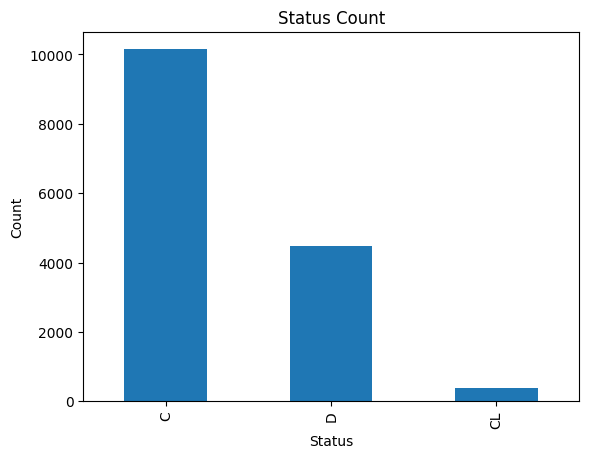

In [100]:
DataSet["Status"].value_counts().plot(kind="bar")
plt.xlabel("Status")
plt.ylabel("Count")
plt.title("Status Count")
plt.show()

In [101]:
num_col=DataSet.select_dtypes(include=np.number).columns
cat_col=DataSet.select_dtypes(exclude=np.number).columns
num_col,cat_col

(Index(['id', 'N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
        'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
        'Stage'],
       dtype='object'),
 Index(['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Status'], dtype='object'))

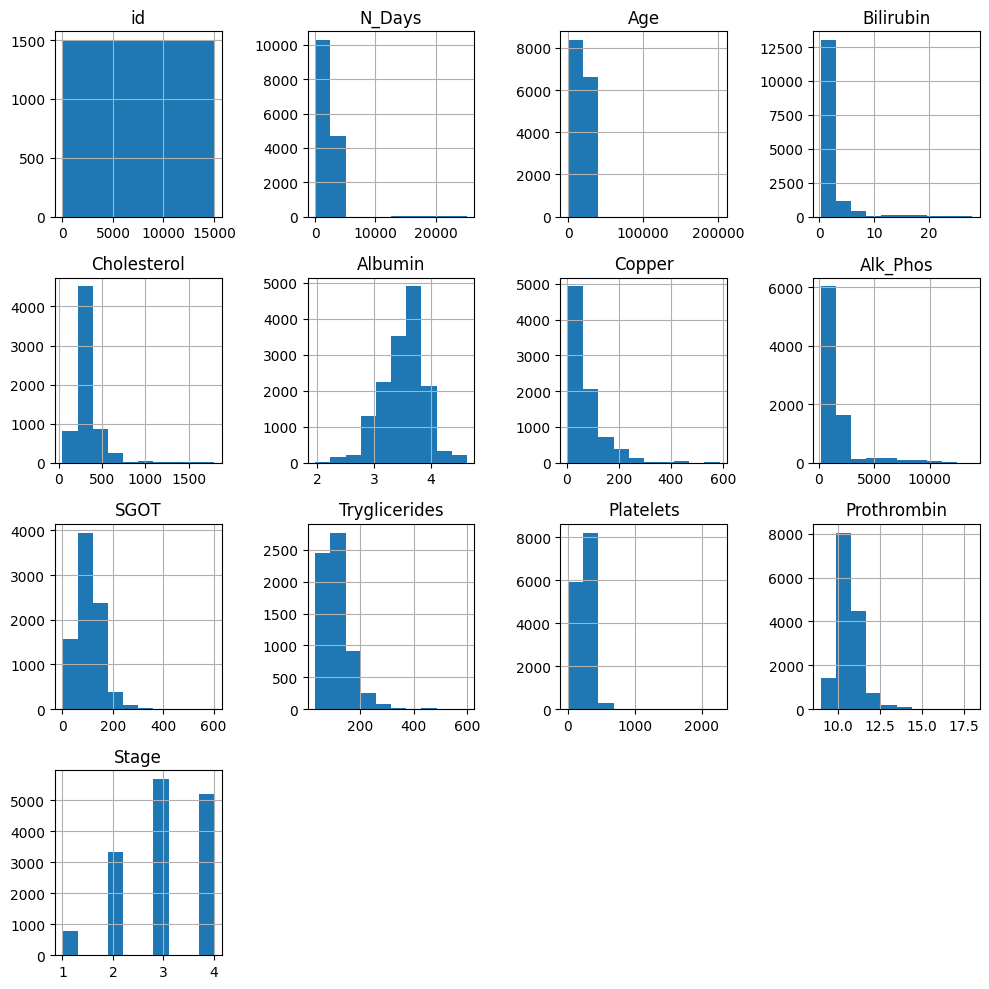

In [102]:
DataSet[num_col].hist(figsize=(10,10))
plt.tight_layout()
plt.show()

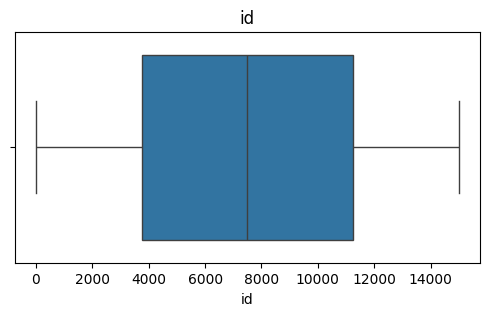

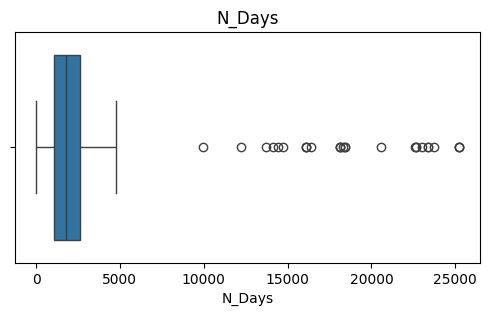

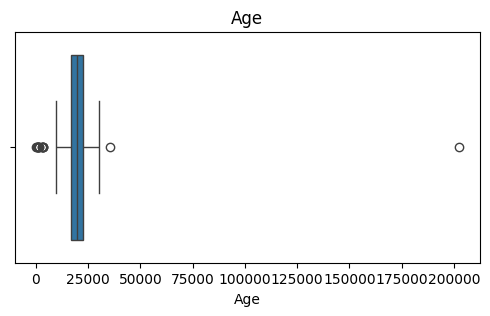

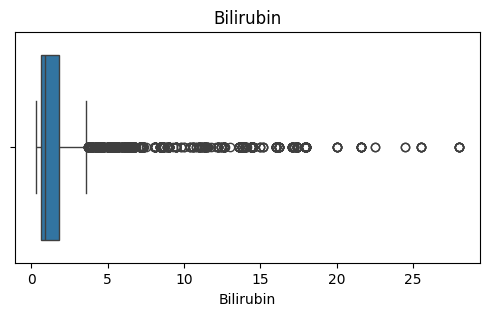

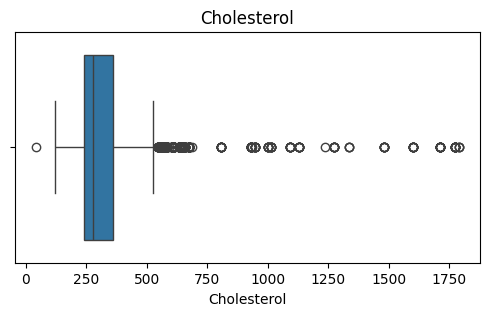

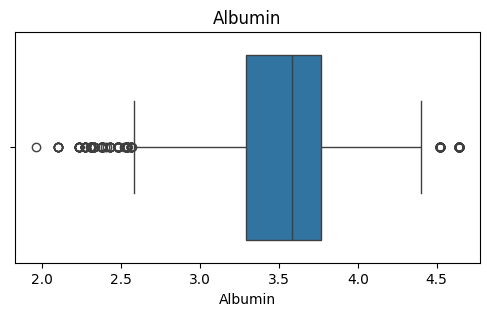

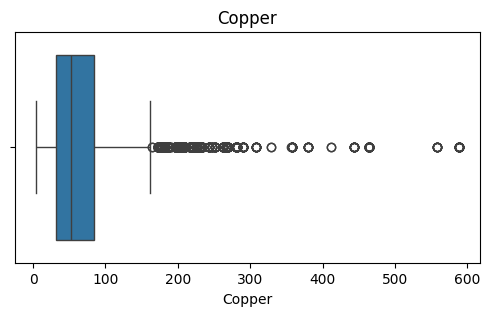

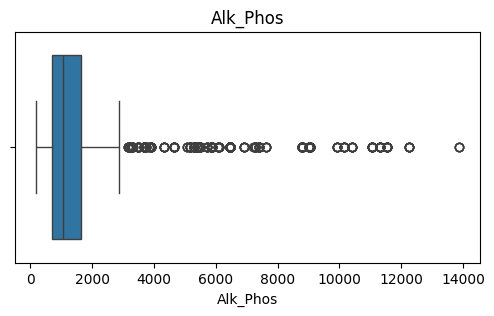

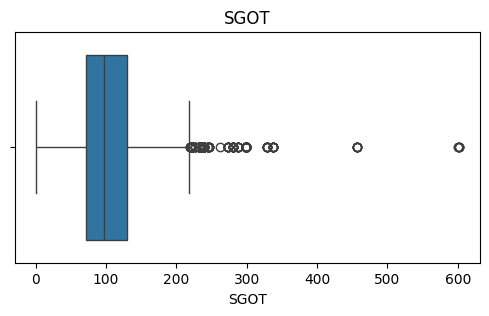

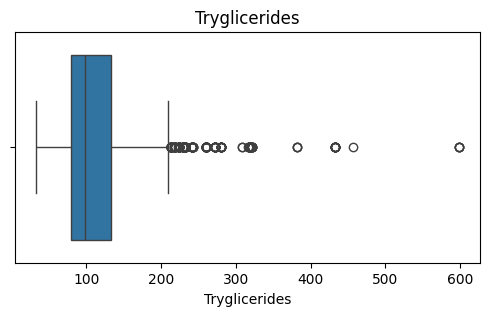

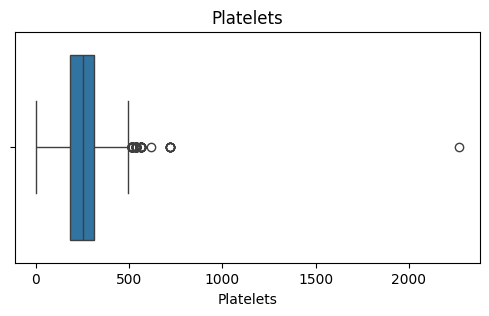

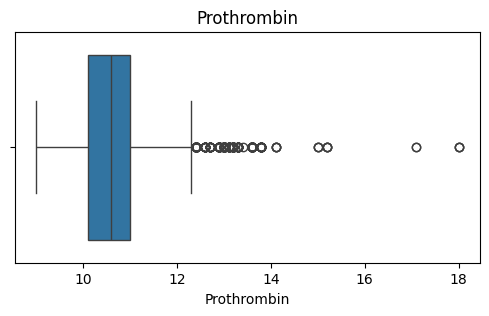

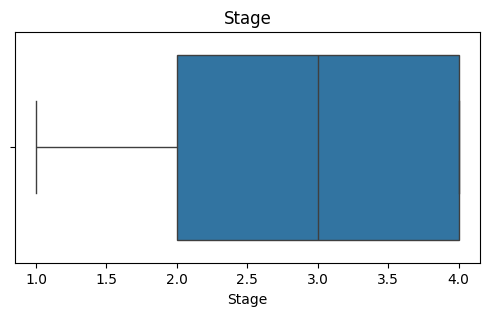

In [103]:
import seaborn as sns
for col in num_col:
  plt.figure(figsize=(6,3))
  sns.boxplot(x=DataSet[col])
  plt.title(col)
  plt.show()

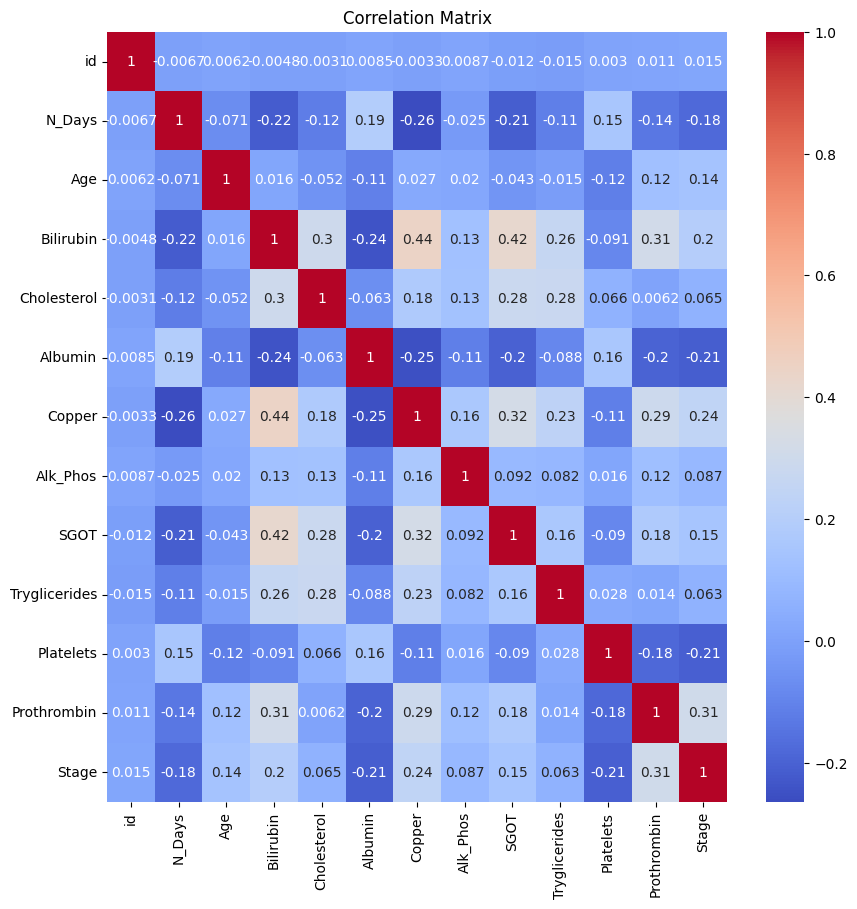

In [104]:
corr_matrix=DataSet[num_col].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [105]:
DataSet = DataSet.drop("id", axis=1)


In [106]:
x=DataSet.drop("Status",axis=1)
y=DataSet["Status"]

# Split the data into training and validation sets using stratification

In [107]:
from sklearn.model_selection import train_test_split
x_train,x_tset,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

## Build preprocessing pipelines for numeric and categorical features

In [108]:
num_col=x_train.select_dtypes(include=np.number).columns
cat_col=x_train.select_dtypes(exclude=np.number).columns
num_col,cat_col

(Index(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
        'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
        'Stage'],
       dtype='object'),
 Index(['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema'], dtype='object'))

In [109]:
x_train.shape,y_train.shape

((12000, 18), (12000,))

In [110]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_col),
    ("cat", cat_pipeline, cat_col)
])

### Encode the multiclass target labels into numeric format

In [111]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_train_enc=le.fit_transform(y_train)
y_test_enc=le.transform(y_test)
print(le.classes_)

['C' 'CL' 'D']


###### Fit the preprocessing pipeline on the training data and transform both sets

In [112]:
x_train_pre=preprocessor.fit_transform(x_train)
x_test_pre=preprocessor.transform(x_tset)

In [113]:
x_train_pre.shape,x_test_pre.shape

((12000, 26), (3000, 26))

In [114]:
print(np.isnan(x_train_pre).sum())
print(np.isnan(x_test_pre).sum())

0
0


#### Tune XGBoost hyperparameters using randomized search with cross-validation

In [115]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_advanced = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42
)

param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.5, 1],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 5]
}

In [116]:
random_search_adv = RandomizedSearchCV(
    estimator=xgb_advanced,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc_ovr",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_adv.fit(x_train_pre, y_train_enc)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_con...
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.5, 1],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [200, 300, 400, 500],
                                        'reg_alpha': [0, 0.01, 0.1, 1],
                                        'reg_lambda': [1, 1.5, 2, 5],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc_ovr', verbose=2)

In [117]:
print("Best parameters:", random_search_adv.best_params_)
print("Best CV score:", random_search_adv.best_score_)

Best parameters: {'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.6}
Best CV score: 0.899547766540631


#### Train the final XGBoost model using the best hyperparameters


In [118]:


xgb_model = XGBClassifier(
    subsample=0.9,
    reg_lambda=5,
    reg_alpha=0.1,
    n_estimators=300,
    min_child_weight=3,
    max_depth=6,
    learning_rate=0.03,
    gamma=0.5,
    colsample_bytree=0.6,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(x_train_pre, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.5,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

#### Evaluate the model using accuracy, ROC-AUC, log loss, and classification metrics

In [119]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, log_loss


best_xgb_adv = random_search_adv.best_estimator_

y_pred_adv = best_xgb_adv.predict(x_test_pre)
y_prob_adv = best_xgb_adv.predict_proba(x_test_pre)

print("Accuracy:", accuracy_score(y_test_enc, y_pred_adv))
print("ROC-AUC:", roc_auc_score(y_test_enc, y_prob_adv, multi_class="ovr"))
print("Log Loss:", log_loss(y_test_enc, y_prob_adv))

print("\nConfusion Matrix:\n", confusion_matrix(y_test_enc, y_pred_adv))
print("\nClassification Report:\n", classification_report(y_test_enc, y_pred_adv))

Accuracy: 0.8456666666666667
ROC-AUC: 0.9237214278753462
Log Loss: 0.38411243184114985

Confusion Matrix:
 [[1898    7  125]
 [  47   10   20]
 [ 262    2  629]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.90      2030
           1       0.53      0.13      0.21        77
           2       0.81      0.70      0.75       893

    accuracy                           0.85      3000
   macro avg       0.73      0.59      0.62      3000
weighted avg       0.84      0.85      0.84      3000



### Load the test dataset and keep the id column for submission

########## Remove the identifier column before preprocessing

In [120]:
test_data = pd.read_csv("test.csv")

In [121]:
test_ids = test_data["id"]

In [122]:
test_data = test_data.drop("id", axis=1)

In [123]:
test_pre = preprocessor.transform(test_data)

print(test_pre.shape)

(10000, 26)


In [124]:
test_prob = xgb_model.predict_proba(test_pre)

print(test_prob[:5])

[[0.9013392  0.06378652 0.03487427]
 [0.46623    0.02315076 0.5106192 ]
 [0.98983455 0.00108431 0.00908116]
 [0.9664179  0.01006657 0.02351553]
 [0.9753611  0.01087796 0.01376094]]


#### Create the submission dataframe in the required competition format

In [125]:
submission = pd.DataFrame({
    "id": test_ids,
    "Status_C": test_prob[:, 0],
    "Status_CL": test_prob[:, 1],
    "Status_D": test_prob[:, 2]
})

submission.head()

,id,Status_C,Status_CL,Status_D
0,15000,0.901339,0.063787,0.034874
1,15001,0.466230,0.023151,0.510619
2,15002,0.989835,0.001084,0.009081
3,15003,0.966418,0.010067,0.023516
4,15004,0.975361,0.010878,0.013761


In [127]:
submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully")

submission.csv saved successfully


# Conclusion

In this project, we built a multiclass classification pipeline for cirrhosis outcomes prediction.
We handled missing values, encoded categorical variables, tuned XGBoost hyperparameters, and evaluated the model using ROC-AUC and Log Loss.
The final model produced probability predictions for the three target classes and generated the required submission file.